In [ ]:
import copy

import hydra
import pandas
import timm

from src.data import get_dataloader
from src.models import *
from src.utils import clean_state_dict


def load_checkpoint(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    state_dict = clean_state_dict(checkpoint['state_dict'])
    model.load_state_dict(state_dict)


methods = ['ADD', 'Sub']
architecture = ['33', '333', 'Inception', 'InceptionV2', 'InceptionV3']
weight_name = 'model_best.pth.tar'
weight_root = 'archive'

with hydra.initialize(config_path='configs', version_base='1.3'):
    cfg = hydra.compose(config_name='sub_resnet', overrides=['local_rank=0', 'train.batch_size=100'])

device = torch.device(f'cuda:{cfg.local_rank}') if torch.cuda.is_available() else torch.device('cpu')
valid_loader = get_dataloader(cfg)[-1]
data = next(iter(valid_loader))

In [ ]:
import torch
import os
from tqdm import tqdm


def forward(model, loader, device):
    pred = list()
    ys = list()
    for data in tqdm(loader, total=len(loader), leave=False):
        x, y = data[0].to(device), data[1].to(device)
        out = model(x)
        pred.append(out.argmax(-1))
        ys.append(y)
    return torch.concat(pred), torch.concat(ys)


@torch.no_grad()
def main():
    connectivity = f'{methods[1]}{architecture[3]}'
    model_name = f'resnet18_{connectivity}'
    model = timm.create_model(
        model_name,
        pretrained=False,
        in_chans=cfg.dataset.in_channels,
        num_classes=cfg.dataset.num_classes,
    )
    load_checkpoint(model, os.path.join(weight_root, connectivity, weight_name))
    model.eval()
    model = model.to(device)
    # deploy(model, BasicBlockSub)

    pred, ys = forward(model, valid_loader, device)
    acc = pred.eq(ys).float().mean()
    df = pandas.DataFrame([['origin', acc.detach().cpu().item() * 100]])
    print("origin: ", acc)

    for name, module in model.named_modules()[1:]:
        if isinstance(module, torch.nn.Conv2d):
            print(name)
            _module_data = copy.deepcopy(module.weight.data)
            module.weight.data.fill_(0.0)

            pred, ys = forward(model, valid_loader, device)
            acc = pred.eq(ys).float().mean()
            df = pandas.concat([df, pandas.DataFrame([[name, acc.detach().cpu().item() * 100]])])

            module.weight.data = _module_data

    df.columns = ['SkipConvName', 'Accuracy']
    print(df.describe())
    print(df)
    df.to_csv(f'{model_name}.csv')


main()

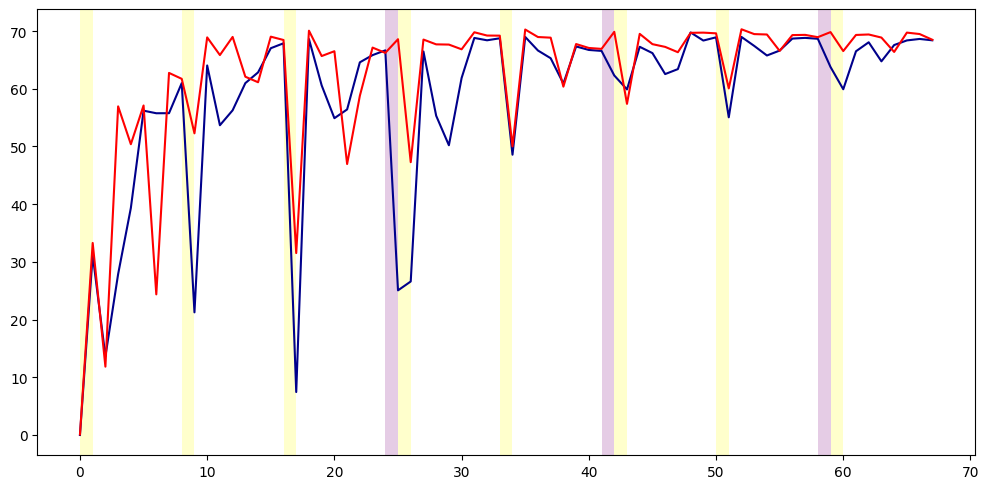

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('assets/resnet18_ADDInceptionV2.csv')
df = df.drop('Unnamed: 0', axis=1)
# print(df[df['SkipConvName'].str.contains('kxk')])
acc = df['Accuracy'][1:].to_list()
names = df['SkipConvName'][1:].to_list()

df_sub = pd.read_csv('assets/resnet18_SubInceptionV2.csv')
df_sub = df_sub.drop('Unnamed: 0', axis=1)
acc_sub = df_sub['Accuracy'][1:].to_list()
names = df_sub['SkipConvName'][1:].to_list()

fig = plt.figure(figsize=(10, 5))
plt.plot(acc, color='darkblue', label='add')
plt.plot(acc_sub, color='red', label='sub')

for i, name in enumerate(names):
    color = None
    if 'conv1.blocks.kxk' in name:
        color = 'yellow'
    # elif '1x1' in name:
    #     color = 'purple'
    # elif '1x3' in name:
    #     color = 'green'
    # elif '3x1' in name:
    #     color = 'orange'
    elif 'downsample' in name:
        color = 'purple'

    if color:
        plt.axvspan(i-1, i, facecolor=color, alpha=0.2)

fig.tight_layout()
plt.savefig(f'assets/drop_block.svg', dpi=500)
plt.show()
